In [1]:
from datasets import load_dataset, Audio

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("badrex/nnti-dataset-full")
ds = ds.cast_column("audio_filepath", Audio(decode=False))

/Users/muhammadsaqib/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/muhammadsaqib/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Explore the dataset structure
print("Dataset keys:", ds.keys())
for split in ds.keys():
    print(f"\n{split} split:")
    print(f"Number of samples: {len(ds[split])}")
    print(f"Features: {ds[split].features}")
    print(f"Column names: {ds[split].column_names}")

Dataset keys: dict_keys(['train', 'validation'])

train split:
Number of samples: 8689
Features: {'audio_filepath': Audio(sampling_rate=None, decode=True, num_channels=None, stream_index=None), 'duration': Value('float64'), 'speaker_id': Value('string'), 'scenario': Value('string'), 'age_group': Value('string'), 'job_type': Value('string'), 'area': Value('string'), 'language': Value('string')}
Column names: ['audio_filepath', 'duration', 'speaker_id', 'scenario', 'age_group', 'job_type', 'area', 'language']

validation split:
Number of samples: 3300
Features: {'audio_filepath': Audio(sampling_rate=None, decode=True, num_channels=None, stream_index=None), 'duration': Value('float64'), 'speaker_id': Value('string'), 'scenario': Value('string'), 'age_group': Value('string'), 'job_type': Value('string'), 'area': Value('string'), 'language': Value('string')}
Column names: ['audio_filepath', 'duration', 'speaker_id', 'scenario', 'age_group', 'job_type', 'area', 'language']


In [3]:
# Look at the features and column names
print("Column names:", ds['train'].column_names)
print("Features:")
for name, feature in ds['train'].features.items():
    print(f"  {name}: {feature}")

Column names: ['audio_filepath', 'duration', 'speaker_id', 'scenario', 'age_group', 'job_type', 'area', 'language']
Features:
  audio_filepath: Audio(sampling_rate=None, decode=True, num_channels=None, stream_index=None)
  duration: Value('float64')
  speaker_id: Value('string')
  scenario: Value('string')
  age_group: Value('string')
  job_type: Value('string')
  area: Value('string')
  language: Value('string')


In [ ]:
import pandas as pd

df = ds['train'].to_pandas()
print("DataFrame shape:", df.shape)
print("DataFrame head:")
print(df.head())

DataFrame shape: (8689, 8)
DataFrame head:
                                      audio_filepath  duration  \
0  {'bytes': b'fLaC\x00\x00\x00"\x10\x00\x10\x00\...     6.111   
1  {'bytes': b'fLaC\x00\x00\x00"\x10\x00\x10\x00\...     4.087   
2  {'bytes': b'fLaC\x00\x00\x00"\x10\x00\x10\x00\...     4.333   
3  {'bytes': b'fLaC\x00\x00\x00"\x10\x00\x10\x00\...     4.094   
4  {'bytes': b'fLaC\x00\x00\x00"\x10\x00\x10\x00\...     6.947   

          speaker_id      scenario age_group      job_type   area  language  
0  S4259249000393906     Extempore     45-60  White Collar  Rural   konkani  
1  S4259542700359117     Extempore     30-45  White Collar  Rural     hindi  
2  S4257289800302440     Extempore     18-30  White Collar  Rural  sanskrit  
3  S4258698300397206     Extempore     18-30       Student  Rural   santali  
4  S4259245900342382  Conversation     45-60   Blue Collar  Rural   marathi  


Matplotlib is building the font cache; this may take a moment.


Language distribution:
language
telugu       400
kannada      400
assamese     400
manipuri     400
dogri        400
nepali       400
malayalam    400
punjabi      400
hindi        400
maithili     400
gujarati     400
tamil        400
bodo         400
kashmiri     400
sindhi       400
marathi      400
santali      400
sanskrit     400
urdu         400
bengali      379
odia         373
konkani      337
Name: count, dtype: int64


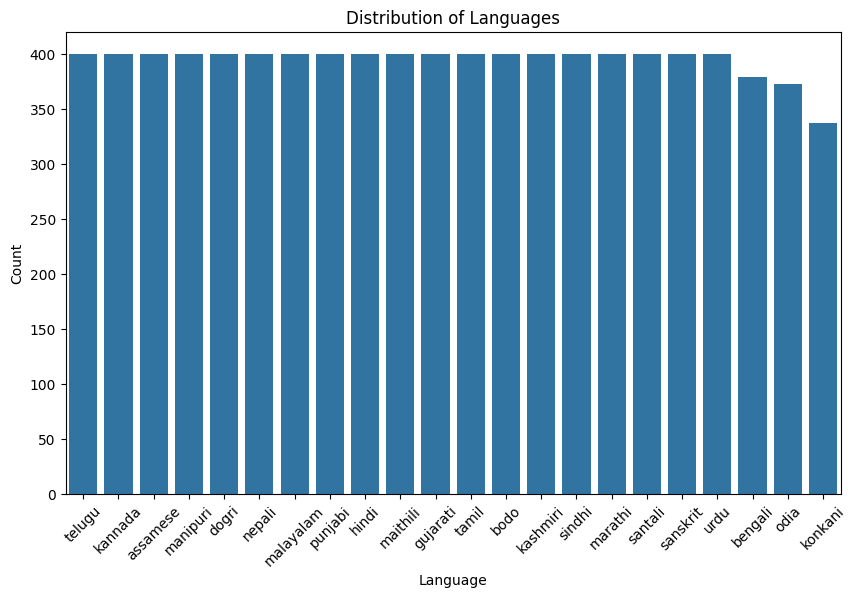

In [5]:
# EDA: Distribution of languages
import matplotlib.pyplot as plt
import seaborn as sns

print("Language distribution:")
lang_counts = df['language'].value_counts()
print(lang_counts)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=lang_counts.index, y=lang_counts.values)
plt.title('Distribution of Languages')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Duration statistics per language:
           count      mean       std       min      25%       50%      75%  \
language                                                                     
assamese   400.0  5.435621  0.876927  4.000000  4.67200  5.403000  6.11200   
bengali    379.0  5.417880  0.886638  4.000000  4.67250  5.381000  6.11300   
bodo       400.0  5.693342  0.808397  4.000000  5.15200  5.727000  6.30400   
dogri      400.0  5.548603  0.878459  4.000000  4.86900  5.500000  6.30400   
gujarati   400.0  5.693593  0.858831  4.000000  5.05875  5.730500  6.40425   
hindi      400.0  5.491005  0.878457  4.000000  4.70225  5.439031  6.20800   
kannada    400.0  5.616837  0.856541  4.000000  4.95875  5.633000  6.30525   
kashmiri   400.0  5.444228  0.876605  4.000000  4.67200  5.440000  6.20625   
konkani    337.0  5.486793  0.898986  3.999062  4.76800  5.442000  6.20800   
maithili   400.0  5.289077  0.879508  4.000000  4.48125  5.153000  6.01300   
malayalam  400.0  5.352068  0.

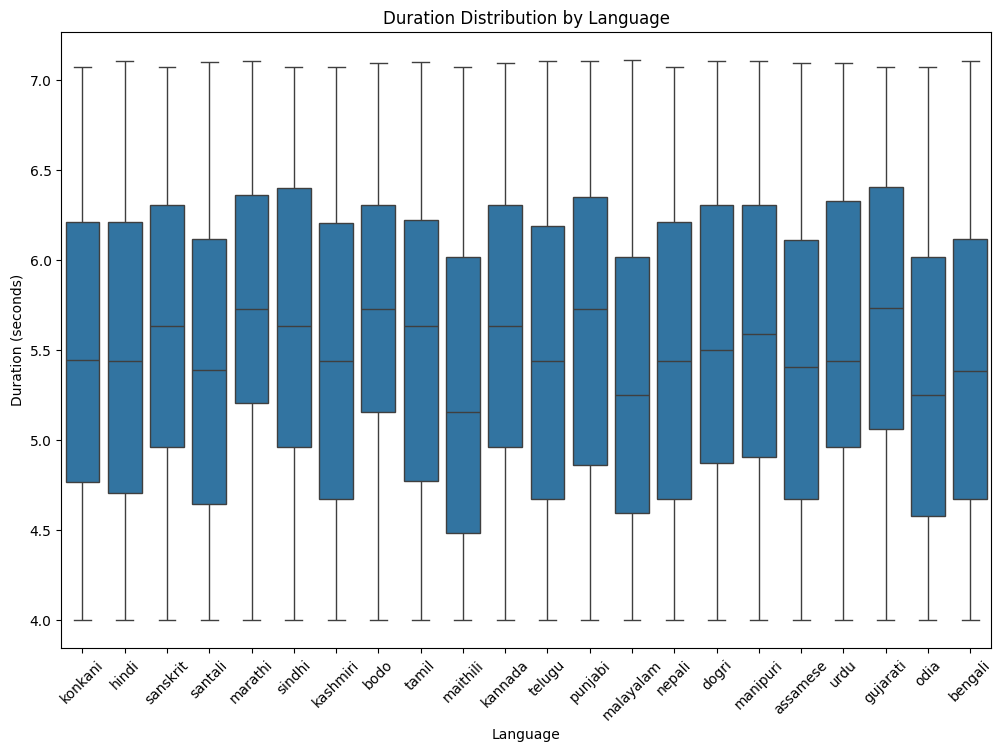

In [6]:
# Duration statistics per language
print("Duration statistics per language:")
duration_stats = df.groupby('language')['duration'].describe()
print(duration_stats)

# Boxplot of duration by language
plt.figure(figsize=(12, 8))
sns.boxplot(x='language', y='duration', data=df)
plt.title('Duration Distribution by Language')
plt.xlabel('Language')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.show()

Scenario distribution per language:
scenario   Conversation  Extempore  Read
language                                
assamese             94        289    17
bengali              43        315    21
bodo                 93        297    10
dogri               331         65     4
gujarati             47        345     8
hindi                90        305     5
kannada              52        327    21
kashmiri            244        141    15
konkani              62        253    22
maithili             86        312     2
malayalam           342         49     9
manipuri            130        252    18
marathi              65        317    18
nepali              307         88     5
odia                 76        276    21
punjabi              40        343    17
sanskrit             50        347     3
santali              80        309    11
sindhi               92        293    15
tamil               194        196    10
telugu              346         44    10
urdu                1

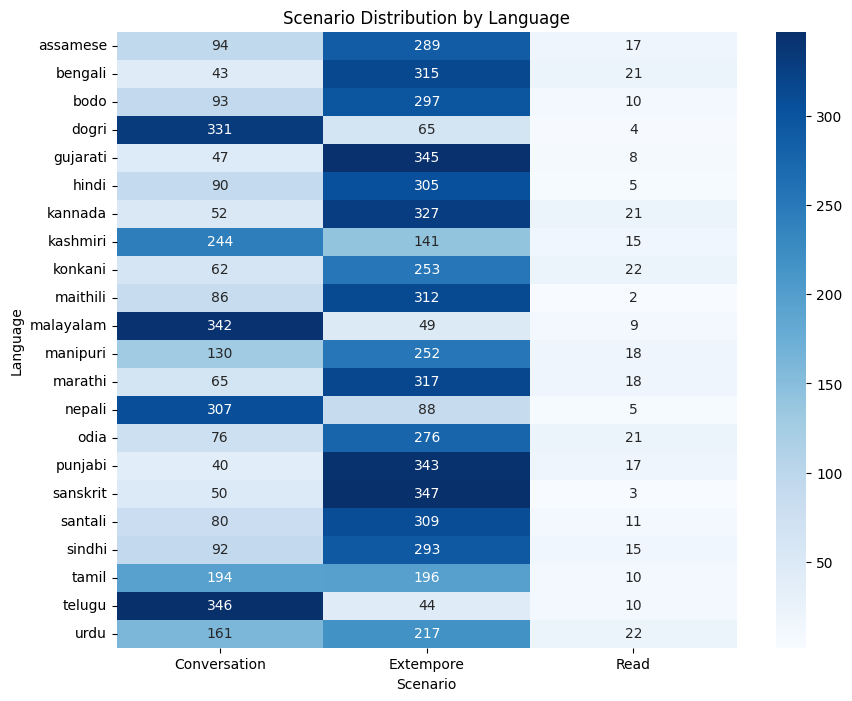

In [7]:
# Scenario distribution per language
scenario_lang = pd.crosstab(df['language'], df['scenario'])
print("Scenario distribution per language:")
print(scenario_lang)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(scenario_lang, annot=True, fmt='d', cmap='Blues')
plt.title('Scenario Distribution by Language')
plt.xlabel('Scenario')
plt.ylabel('Language')
plt.show()

Age group distribution per language:
age_group  18-30  30-45  45-60  60+
language                           
assamese       0    221     71  108
bengali        0      0    211  168
bodo         104    213     83    0
dogri        350     50      0    0
gujarati      85    181    134    0
hindi         54    177    169    0
kannada      122    171     81   26
kashmiri      65    335      0    0
konkani      164      0    173    0
maithili       0      0    109  291
malayalam    400      0      0    0
manipuri     172    228      0    0
marathi      149      0    251    0
nepali        85    249      0   66
odia         155     72      0  146
punjabi      179     78    143    0
sanskrit      90    237      0   73
santali      154      0    153   93
sindhi       158    100     85   57
tamil         65    221    114    0
telugu       400      0      0    0
urdu         330      0     70    0


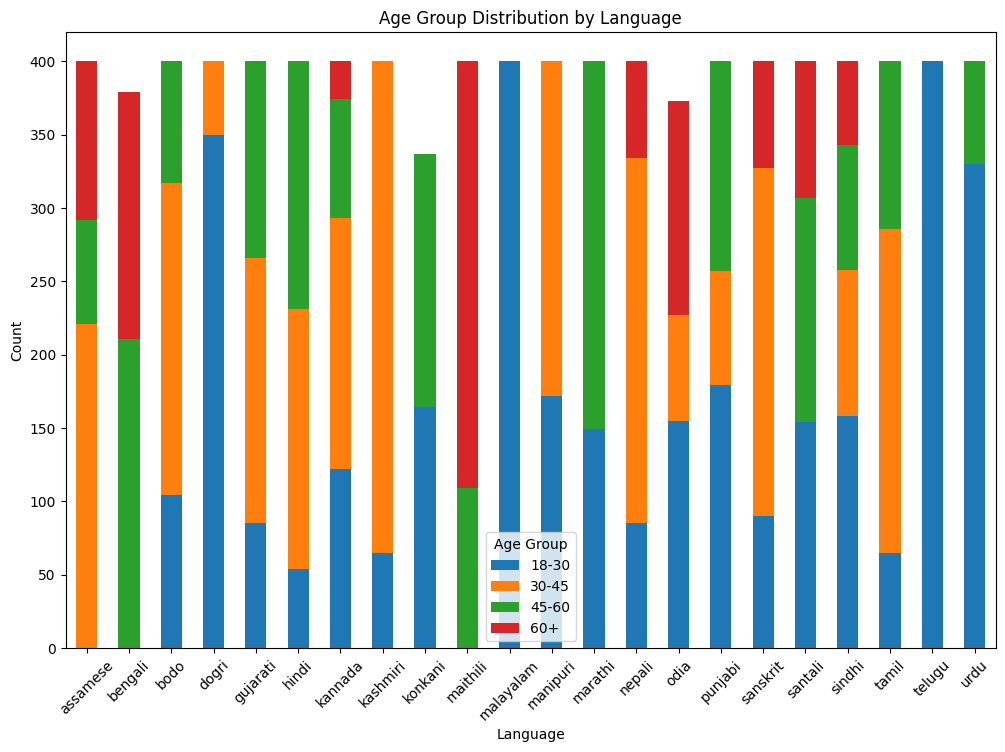

In [8]:
# Age group distribution per language
age_lang = pd.crosstab(df['language'], df['age_group'])
print("Age group distribution per language:")
print(age_lang)

# Stacked bar plot
age_lang.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Age Group Distribution by Language')
plt.xlabel('Language')
plt.ylabel('Count')
plt.legend(title='Age Group')
plt.xticks(rotation=45)
plt.show()

Job type distribution per language:
job_type   Blue Collar  Student  Unemployed  White Collar
language                                                 
assamese            71        0         264            65
bengali            215        0           0           164
bodo                 0        0         228           172
dogri              103      100         197             0
gujarati            60       85         119           136
hindi                0       54           0           346
kannada            107        0         293             0
kashmiri           106       65          64           165
konkani             45       69          37           186
maithili           313        0           0            87
malayalam          193      118          89             0
manipuri            69      172         159             0
marathi            219       51           0           130
nepali              76       85         239             0
odia                72      155     

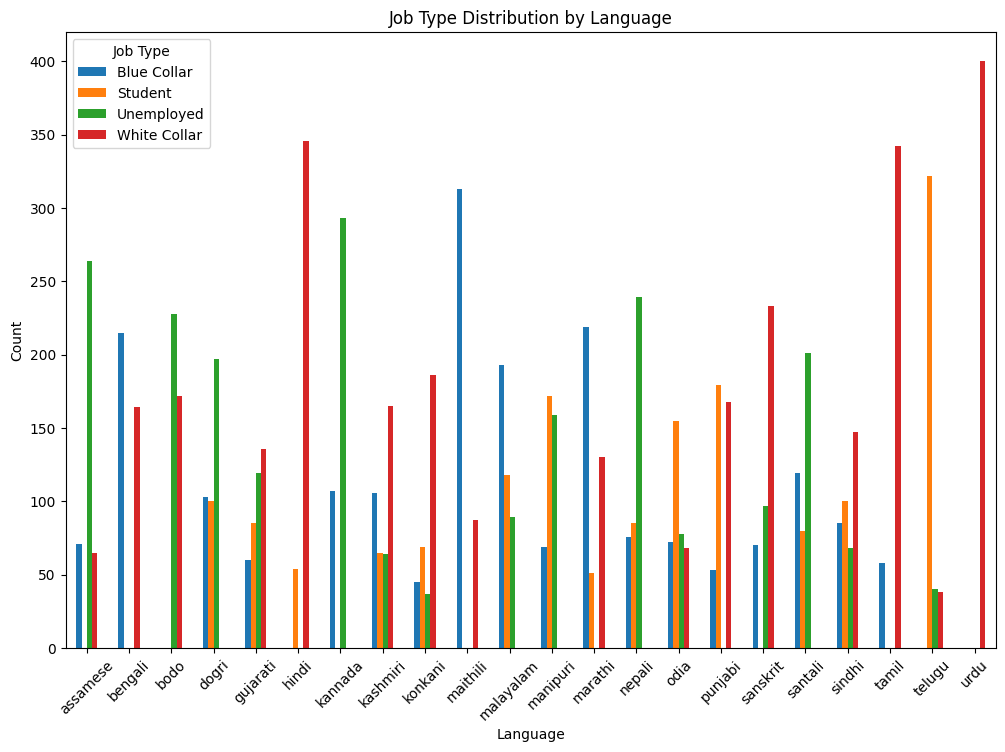

In [9]:
# Job type distribution per language
job_lang = pd.crosstab(df['language'], df['job_type'])
print("Job type distribution per language:")
print(job_lang)

# Bar plot
job_lang.plot(kind='bar', figsize=(12, 8))
plt.title('Job Type Distribution by Language')
plt.xlabel('Language')
plt.ylabel('Count')
plt.legend(title='Job Type')
plt.xticks(rotation=45)
plt.show()

Area distribution per language:
area       Rural  Urban
language               
assamese      63    337
bengali       91    288
bodo         124    276
dogri        350     50
gujarati     204    196
hindi        177    223
kannada      400      0
kashmiri     400      0
konkani      337      0
maithili     246    154
malayalam    400      0
manipuri     400      0
marathi      219    181
nepali       400      0
odia         233    140
punjabi      171    229
sanskrit     230    170
santali      307     93
sindhi        57    343
tamil        286    114
telugu       320     80
urdu           0    400


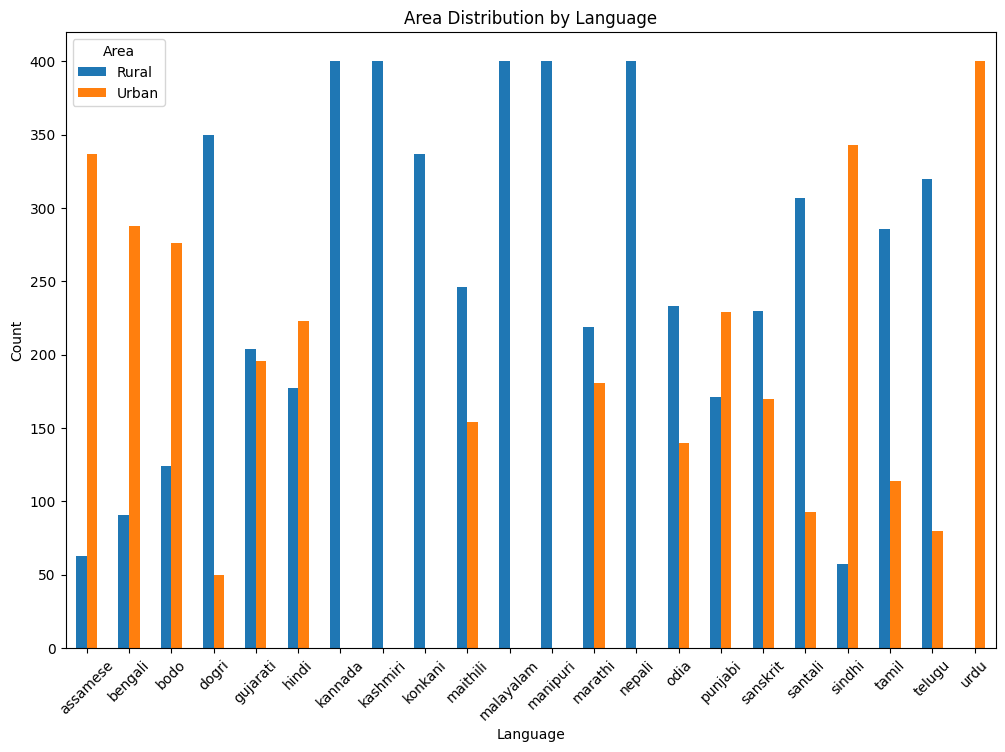

In [10]:
# Area distribution per language
area_lang = pd.crosstab(df['language'], df['area'])
print("Area distribution per language:")
print(area_lang)

# Pie chart for each language or bar
area_lang.plot(kind='bar', figsize=(12, 8))
plt.title('Area Distribution by Language')
plt.xlabel('Language')
plt.ylabel('Count')
plt.legend(title='Area')
plt.xticks(rotation=45)
plt.show()

Unique speakers per language:
language
assamese     5
bengali      5
bodo         5
dogri        5
gujarati     5
hindi        5
kannada      5
kashmiri     5
konkani      5
maithili     5
malayalam    5
manipuri     5
marathi      5
nepali       5
odia         5
punjabi      5
sanskrit     5
santali      5
sindhi       5
tamil        5
telugu       5
urdu         5
Name: speaker_id, dtype: int64


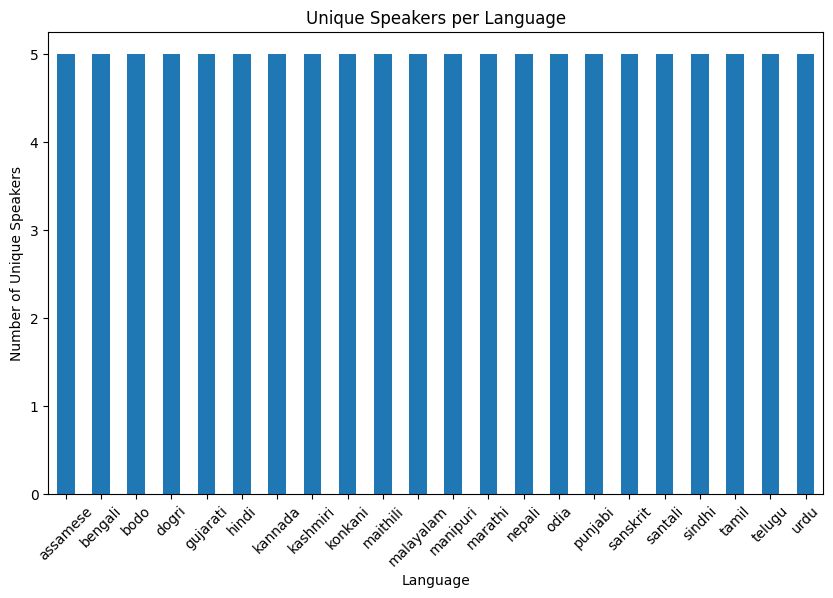

In [11]:
# Unique speakers per language
unique_speakers = df.groupby('language')['speaker_id'].nunique()
print("Unique speakers per language:")
print(unique_speakers)

# Plot
plt.figure(figsize=(10, 6))
unique_speakers.plot(kind='bar')
plt.title('Unique Speakers per Language')
plt.xlabel('Language')
plt.ylabel('Number of Unique Speakers')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Summary statistics for numerical columns
print("\nSummary statistics for duration:")
print(df['duration'].describe())

Missing values per column:
audio_filepath    0
duration          0
speaker_id        0
scenario          0
age_group         0
job_type          0
area              0
language          0
dtype: int64

Summary statistics for duration:
count    8689.000000
mean        5.517067
std         0.879978
min         3.999062
25%         4.768000
50%         5.531000
75%         6.232000
max         7.110000
Name: duration, dtype: float64


Average duration per language:
language
maithili     5.289077
odia         5.318898
malayalam    5.352068
bengali      5.417880
santali      5.420742
telugu       5.433384
assamese     5.435621
kashmiri     5.444228
nepali       5.457203
konkani      5.486793
hindi        5.491005
tamil        5.540223
dogri        5.548603
urdu         5.563593
manipuri     5.575116
sanskrit     5.596320
kannada      5.616837
punjabi      5.620490
sindhi       5.628635
bodo         5.693342
gujarati     5.693593
marathi      5.728465
Name: duration, dtype: float64


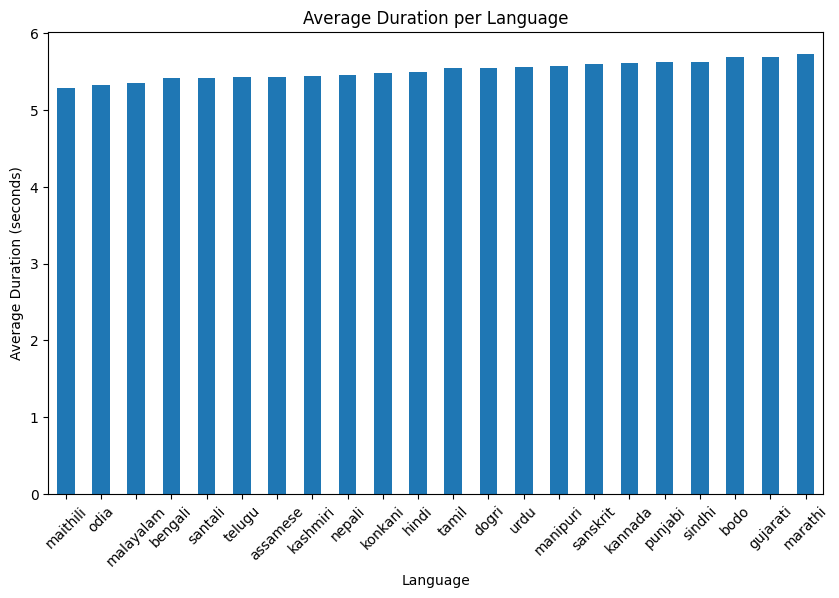

In [13]:
# Average duration per language
avg_duration = df.groupby('language')['duration'].mean().sort_values()
print("Average duration per language:")
print(avg_duration)

# Plot
plt.figure(figsize=(10, 6))
avg_duration.plot(kind='bar')
plt.title('Average Duration per Language')
plt.xlabel('Language')
plt.ylabel('Average Duration (seconds)')
plt.xticks(rotation=45)
plt.show()

Unique speakers per language:
language
assamese     5
bengali      5
bodo         5
dogri        5
gujarati     5
hindi        5
kannada      5
kashmiri     5
konkani      5
maithili     5
malayalam    5
manipuri     5
marathi      5
nepali       5
odia         5
punjabi      5
sanskrit     5
santali      5
sindhi       5
tamil        5
telugu       5
urdu         5
Name: speaker_id, dtype: int64
All languages have exactly 5 unique speakers. This can lead to speaker memorization!


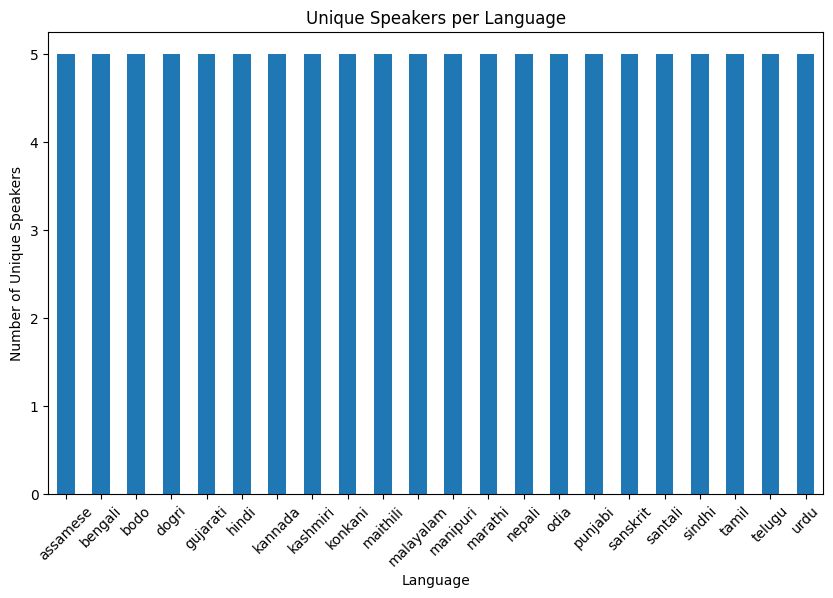

Samples per speaker (first 20):
language  speaker_id       
assamese  S4258234400382974     93
          S4258795500341378    108
          S4259020500311683     65
          S4259066000377409     71
          S4259615600384226     63
bengali   S4257692800334751     73
          S4258703800332030     47
          S4258903000331485     91
          S4259007600380255     78
          S4259313200393314     90
bodo      S4256035800300081    104
          S4256062900302870     50
          S4257025200302460     89
          S4259066600311536     83
          S4259086400358413     74
dogri     S4256093900306432     59
          S4257043200306062    147
          S4257091000306186     50
          S4257891300370212     41
          S4258990400342819    103
dtype: int64
Min samples per speaker: 26
Max samples per speaker: 147
Mean samples per speaker: 78.99090909090908


In [5]:
# Analyze speaker distribution per language
speaker_per_lang = df.groupby('language')['speaker_id'].nunique()
print("Unique speakers per language:")
print(speaker_per_lang)

# Check if all languages have exactly 5 speakers
if all(speaker_per_lang == 5):
    print("All languages have exactly 5 unique speakers. This can lead to speaker memorization!")
else:
    print("Speaker counts vary across languages.")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
speaker_per_lang.plot(kind='bar')
plt.title('Unique Speakers per Language')
plt.xlabel('Language')
plt.ylabel('Number of Unique Speakers')
plt.xticks(rotation=45)
plt.show()

# Analyze samples per speaker
samples_per_speaker = df.groupby(['language', 'speaker_id']).size()
print("Samples per speaker (first 20):")
print(samples_per_speaker.head(20))

# Check for imbalance
print(f"Min samples per speaker: {samples_per_speaker.min()}")
print(f"Max samples per speaker: {samples_per_speaker.max()}")
print(f"Mean samples per speaker: {samples_per_speaker.mean()}")

In [ ]:
# Mitigation: Speaker-aware cross-validation
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
for fold, (train_idx, val_idx) in enumerate(gkf.split(df, groups=df['speaker_id'])):
    train_speakers = df.iloc[train_idx]['speaker_id'].unique()
    val_speakers = df.iloc[val_idx]['speaker_id'].unique()
    print(f"Fold {fold+1}: Train speakers: {len(train_speakers)}, Val speakers: {len(val_speakers)}")
    print(f"Overlap: {set(train_speakers).intersection(set(val_speakers))}")
    break  # Show one fold

Fold 1: Train speakers: 88, Val speakers: 22
Overlap: set()


In [ ]:
# Summary of unique speakers and samples per speaker per language
total_unique_speakers = df['speaker_id'].nunique()
print(f"Total unique speakers in train set: {total_unique_speakers}")

for lang in df['language'].unique():
    lang_df = df[df['language'] == lang]
    samples_per_speaker = lang_df.groupby('speaker_id').size()
    print(f"\nLanguage: {lang}")
    print(f"  Unique speakers: {len(samples_per_speaker)}")
    print(f"  Min samples per speaker: {samples_per_speaker.min()}")
    print(f"  Max samples per speaker: {samples_per_speaker.max()}")
    print(f"  Mean samples per speaker: {samples_per_speaker.mean():.1f}")
    print(f"  Total samples for language: {len(lang_df)}")

print("\n=== OVERALL STATS ===")
overall_samples_per_speaker = df.groupby('speaker_id').size()
print(f"Overall min samples per speaker: {overall_samples_per_speaker.min()}")
print(f"Overall max samples per speaker: {overall_samples_per_speaker.max()}")
print(f"Overall mean samples per speaker: {overall_samples_per_speaker.mean():.1f}")

=== UNIQUE SPEAKERS SUMMARY ===
Total unique speakers in train set: 110

=== SAMPLES PER SPEAKER PER LANGUAGE ===

Language: konkani
  Unique speakers: 5
  Min samples per speaker: 37
  Max samples per speaker: 128
  Mean samples per speaker: 67.4
  Total samples for language: 337

Language: hindi
  Unique speakers: 5
  Min samples per speaker: 54
  Max samples per speaker: 93
  Mean samples per speaker: 80.0
  Total samples for language: 400

Language: sanskrit
  Unique speakers: 5
  Min samples per speaker: 70
  Max samples per speaker: 97
  Mean samples per speaker: 80.0
  Total samples for language: 400

Language: santali
  Unique speakers: 5
  Min samples per speaker: 26
  Max samples per speaker: 127
  Mean samples per speaker: 80.0
  Total samples for language: 400

Language: marathi
  Unique speakers: 5
  Min samples per speaker: 46
  Max samples per speaker: 121
  Mean samples per speaker: 80.0
  Total samples for language: 400

Language: sindhi
  Unique speakers: 5
  Min samp

Original audio stats:
  Length: 97776 samples
  Duration: 6.11 seconds
  Mean amplitude: 0.0766
  RMS: 0.1258

Augmented audio stats:
  Length: 97776 samples
  Duration: 6.11 seconds
  Mean amplitude: 0.0775
  RMS: 0.1263


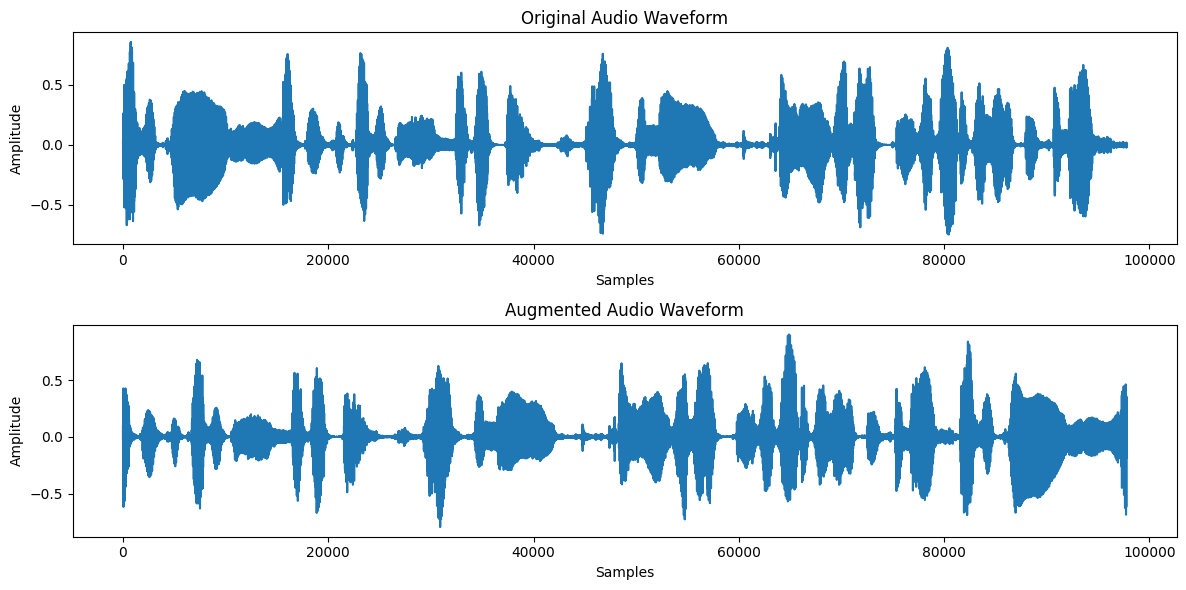

In [4]:
# Apply augmentation to a sample and compare stats
import numpy as np
import librosa
import io

# Load a sample audio
sample = ds['train'][0]
audio_bytes = sample['audio_filepath']['bytes']
original_audio, sr = librosa.load(io.BytesIO(audio_bytes), sr=None)

print("Original audio stats:")
print(f"  Length: {len(original_audio)} samples")
print(f"  Duration: {len(original_audio)/sr:.2f} seconds")
print(f"  Mean amplitude: {np.mean(np.abs(original_audio)):.4f}")
print(f"  RMS: {np.sqrt(np.mean(original_audio**2)):.4f}")

# Apply augmentation
augmented_audio = augment(samples=original_audio, sample_rate=sr)

print("\nAugmented audio stats:")
print(f"  Length: {len(augmented_audio)} samples")
print(f"  Duration: {len(augmented_audio)/sr:.2f} seconds")
print(f"  Mean amplitude: {np.mean(np.abs(augmented_audio)):.4f}")
print(f"  RMS: {np.sqrt(np.mean(augmented_audio**2)):.4f}")

# Plot waveforms
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(original_audio)
plt.title('Original Audio Waveform')
plt.xlabel('Samples')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(augmented_audio)
plt.title('Augmented Audio Waveform')
plt.xlabel('Samples')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [9]:
# Extend dataset with augmented samples, focusing more on speakers with fewer samples
import soundfile as sf
from datasets import Dataset

# Compute samples per speaker
speaker_sample_counts = df.groupby('speaker_id').size().to_dict()

# Function to decide number of augmentations per sample based on speaker's total samples
def get_num_aug(speaker_id):
    count = speaker_sample_counts[speaker_id]
    if count < 50:
        return 4  # More augmentations for speakers with few samples
    elif count < 80:
        return 2
    else:
        return 1

# Function to augment a sample and return list of samples (original + augmented)
def augment_sample(sample):
    speaker_id = sample['speaker_id']
    num_aug = get_num_aug(speaker_id)
    
    # Load original audio
    audio_bytes = sample['audio_filepath']['bytes']
    original_audio, sr = librosa.load(io.BytesIO(audio_bytes), sr=None)
    
    samples_list = [sample]  # Keep original
    
    for _ in range(num_aug):
        # Apply augmentation
        augmented_audio = augment(samples=original_audio, sample_rate=sr)
        
        # Save augmented audio back to bytes (FLAC format)
        buffer = io.BytesIO()
        sf.write(buffer, augmented_audio, sr, format='FLAC')
        aug_bytes = buffer.getvalue()
        
        # Create new sample dict
        aug_sample = sample.copy()
        aug_sample['audio_filepath'] = {'path': sample['audio_filepath']['path'], 'bytes': aug_bytes}
        # Optionally add a flag
        aug_sample['is_augmented'] = True
        samples_list.append(aug_sample)
    
    return samples_list

# Apply to dataset (this will create extended dataset)
print("Extending dataset with augmentations...")
extended_samples = []
for sample in ds['train']:
    extended_samples.extend(augment_sample(sample))

extended_train = Dataset.from_list(extended_samples)
extended_ds = {'train': extended_train, 'validation': ds['validation']}  # Keep validation as is

print(f"Original train dataset size: {len(ds['train'])}")
print(f"Extended train dataset size: {len(extended_ds['train'])}")

# Check new speaker distribution
extended_df = extended_ds['train'].to_pandas()
new_speaker_counts = extended_df.groupby('speaker_id').size()
print("\nNew samples per speaker (first 10):")
print(new_speaker_counts.head(10))
print(f"\nOverall stats - Min: {new_speaker_counts.min()}, Max: {new_speaker_counts.max()}, Mean: {new_speaker_counts.mean():.1f}")

Extending dataset with augmentations...
Original train dataset size: 8689
Extended train dataset size: 21600

New samples per speaker (first 10):
speaker_id
S4256035800300081    208
S4256062900302870    150
S4256065700339019    240
S4256093900306432    177
S4256747700332362    237
S4257025200302460    178
S4257043200306062    294
S4257044600328703    168
S4257073800398579    254
S4257091000306186    150
dtype: int64

Overall stats - Min: 130, Max: 294, Mean: 196.4


In [10]:
# Audio Comparison: Listen to Original vs Augmented Samples
from IPython.display import Audio, HTML, display
import pandas as pd

# Find speakers with different sample counts
speaker_counts_original = df.groupby('speaker_id').size().sort_values()
print("Speaker sample count distribution:")
print(f"Min: {speaker_counts_original.min()}, Q1: {speaker_counts_original.quantile(0.25):.0f}, Median: {speaker_counts_original.median():.0f}, Q3: {speaker_counts_original.quantile(0.75):.0f}, Max: {speaker_counts_original.max()}")

# Select speakers with few samples, median, and many samples
speaker_few = speaker_counts_original.index[0]  # Min samples
speaker_median = speaker_counts_original.index[len(speaker_counts_original)//2]  # Median
speaker_many = speaker_counts_original.index[-1]  # Max samples

selected_speakers = [speaker_few, speaker_median, speaker_many]
print(f"\nSelected speakers for comparison:")
print(f"  Few samples: {speaker_few} ({speaker_counts_original[speaker_few]} samples)")
print(f"  Median: {speaker_median} ({speaker_counts_original[speaker_median]} samples)")
print(f"  Many samples: {speaker_many} ({speaker_counts_original[speaker_many]} samples)")

# Create comparison display for each speaker
for speaker in selected_speakers:
    # Get samples from original and extended datasets
    original_samples = [s for s in ds['train'] if s['speaker_id'] == speaker]
    extended_samples = [s for s in extended_train if s['speaker_id'] == speaker]
    
    if not original_samples:
        continue
    
    num_aug = get_num_aug(speaker)
    print(f"\n{'='*80}")
    print(f"Speaker: {speaker} | Augmentations per sample: {num_aug}")
    print(f"Language: {original_samples[0]['language']} | Original samples: {len(original_samples)}")
    print(f"{'='*80}")
    
    # Display first 2 original samples and their augmentations
    for idx, sample in enumerate(original_samples[:2]):
        # Get original audio
        audio_bytes = sample['audio_filepath']['bytes']
        original_audio_data, sr_sample = librosa.load(io.BytesIO(audio_bytes), sr=None)
        
        # Find all versions of this sample in extended dataset
        sample_idx = ds['train'].to_list().index(sample)
        sample_base_idx = sample_idx * (num_aug + 1)
        
        # Get original and augmented versions from extended dataset
        versions = extended_train[sample_base_idx:sample_base_idx + num_aug + 1]
        
        print(f"\nOriginal Sample #{idx + 1}:")
        print(f"Duration: {sample['duration']:.2f}s | Language: {sample['language']}")
        
        # Display audio players for original + augmentations
        for v_idx, version in enumerate(versions):
            try:
                v_audio_bytes = version['audio_filepath']['bytes']
                audio_data, sr_v = librosa.load(io.BytesIO(v_audio_bytes), sr=None)
                
                if v_idx == 0:
                    label = "🔊 ORIGINAL"
                else:
                    label = f"🔊 AUGMENTED #{v_idx}"
                
                display(HTML(f"<p><b>{label}</b> (Duration: {len(audio_data)/sr_v:.2f}s)</p>"))
                display(Audio(data=audio_data, rate=sr_v))
            except Exception as e:
                print(f"Error loading version {v_idx}: {e}")
        
        print("-" * 80)

Speaker sample count distribution:
Min: 26, Q1: 65, Median: 78, Q3: 91, Max: 147

Selected speakers for comparison:
  Few samples: S4258661200381336 (26 samples)
  Median: S4259613800383941 (79 samples)
  Many samples: S4257043200306062 (147 samples)

Speaker: S4258661200381336 | Augmentations per sample: 4
Language: kannada | Original samples: 26

Original Sample #1:
Duration: 5.44s | Language: kannada
Error loading version 0: string indices must be integers
Error loading version 1: string indices must be integers
Error loading version 2: string indices must be integers
Error loading version 3: string indices must be integers
Error loading version 4: string indices must be integers
Error loading version 5: string indices must be integers
Error loading version 6: string indices must be integers
Error loading version 7: string indices must be integers
--------------------------------------------------------------------------------

Original Sample #2:
Duration: 4.57s | Language: kannada